In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.signal as sig
import scipy.io.wavfile as wav
import scipy.optimize as opt
import scipy.io as sio
import scipy.ndimage as nd
import scipy.stats as stats
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import gaussian


In [3]:
sound = np.load("sim_output_no_reflections/simulated_cabin_audio.npz")

In [8]:
mic_signals = sound['mic_signals']
mic_signals.shape

(4, 96000)

In [ ]:
drive_mic = mic_signals[0]
passenger_mic = mic_signals[1]
rl_mic = mic_signals[2]
rr_mic = mic_signals[3]
fs = sound['fs'] 
drive_mic.shape
passenger_mic.shape

(96000,)

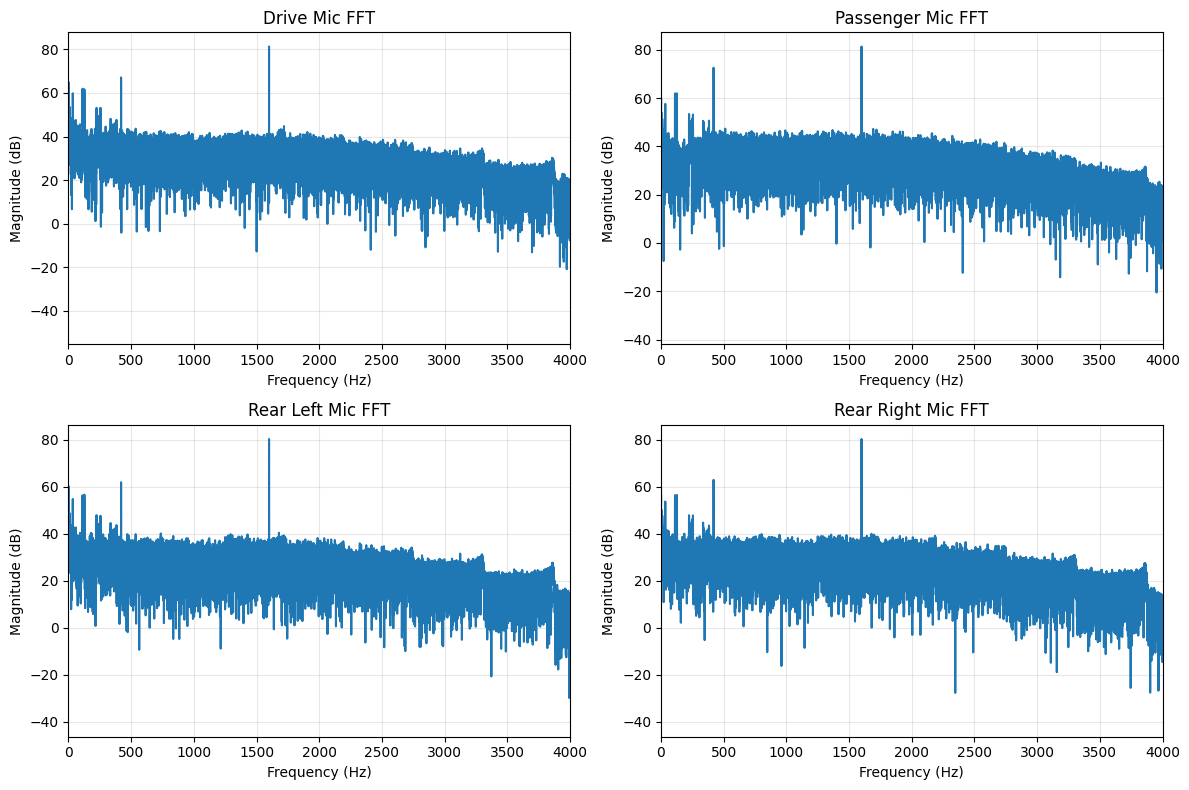

In [42]:
plt.figure(figsize=(12, 8))

mic_labels = ["Drive Mic", "Passenger Mic", "Rear Left Mic", "Rear Right Mic"]
mic_data = [drive_mic, passenger_mic, rl_mic, rr_mic]

for i, (mic, label) in enumerate(zip(mic_data, mic_labels)):
    plt.subplot(2, 2, i + 1)
    N = len(mic)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.fft.rfft(mic)
    magnitude = np.abs(fft_vals)
    peaks = sig.find_peaks(magnitude, height=40, prominence=3)
    plt.plot(freqs, 20*np.log10(magnitude + 1e-12))
    plt.title(f"{label} FFT")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(alpha=0.3)
    plt.xlim(0, 4000)

plt.tight_layout()
plt.show()

In [45]:
peaks[0].shape

(2885,)

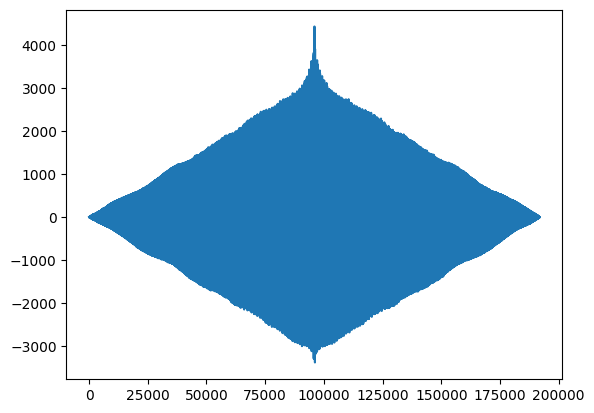

In [23]:
cross_corr = scipy.signal.correlate(drive_mic, passenger_mic)
plt.plot(cross_corr)

Text(0.5, 1.0, 'Passenger Mic Spectrogram')

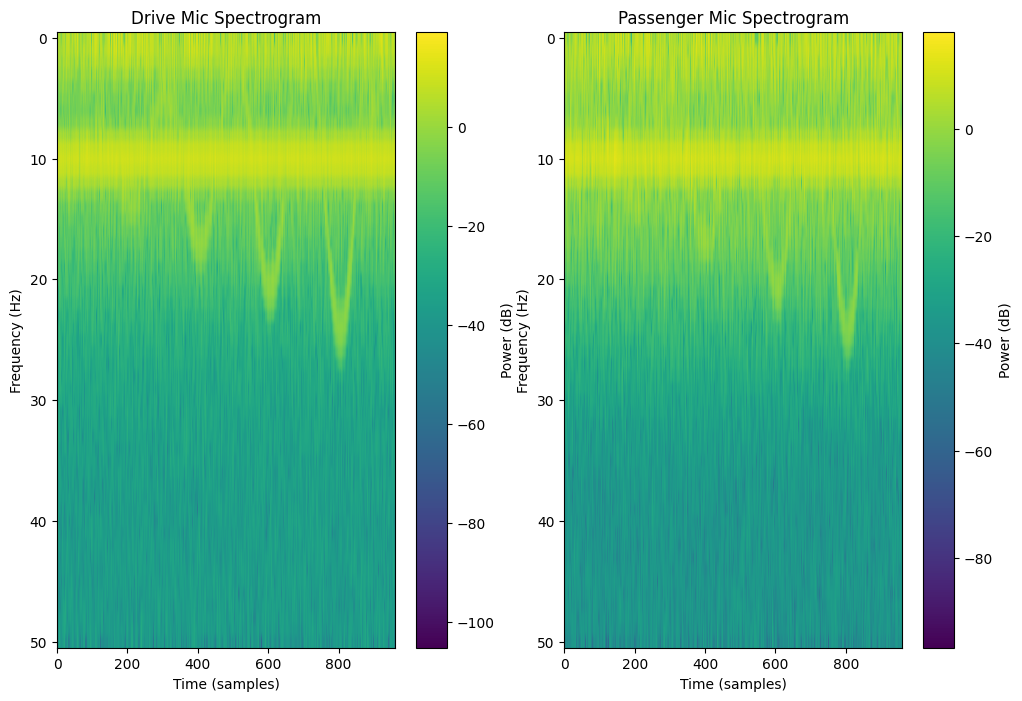

In [38]:
window = gaussian(100, 10, sym=True)
sft = ShortTimeFFT(window, 100, fs=16000)
N = len(drive_mic)
drive_mic_sft = sft.spectrogram(drive_mic)
passenger_mic_sft = sft.spectrogram(passenger_mic)

t_lo, t_hi = sft.extent(N)[:2]

drive_mic_sft = 10 * np.log10(drive_mic_sft + 1e-12)
passenger_mic_sft = 10 * np.log10(passenger_mic_sft + 1e-12)

fig, ax = plt.subplots(ncols=2, figsize=(12, 8))
im = ax[0].imshow(drive_mic_sft, aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax[0], label="Power (dB)")
ax[0].set_xlabel("Time (samples)")
ax[0].set_ylabel("Frequency (Hz)")
ax[0].set_title("Drive Mic Spectrogram")

im = ax[1].imshow(passenger_mic_sft, aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax[1], label="Power (dB)")
ax[1].set_xlabel("Time (samples)")
ax[1].set_ylabel("Frequency (Hz)")
ax[1].set_title("Passenger Mic Spectrogram")



In [29]:
drive_mic_sft.shape

(51, 961)

In [37]:
fs

array(16000)